# Absorbing Subjects — Control de Calidad EEG

Análisis de calidad de señal para los sujetos identificados como **absorbentes**  
(FO > 0.95 en un estado) en `deep_analysis_v2.ipynb`.

**Objetivo:** Determinar si la absorción refleja una dinámica neuronal genuina  
o un artefacto (EMG, canal ruidoso, movimiento).

---

| Bloque | Contenido |
|---|---|
| B0 | Configuración — IDs, rutas, umbrales |
| B1 | Función `analyze_subject()` |
| B2 | QC individual — tabla + semáforo |
| B3 | Comparación Absorbentes vs Controles |
| B4 | Espectros de potencia (EMG check) |
| B5 | Topomapas RMS |
| B6 | Veredictos: Artefacto / Atípico / OK |

In [1]:
# ============================================================
# BLOQUE 0 — CONFIGURACIÓN
# ============================================================

PROJECT_NAME = "eeg_hmm_plattform"

# Directorio con archivos .fif de epochs preprocesados
FIF_DIR = "C:/Users/pokem/OneDrive/Desktop/lab 2026/EEG_Preprocesado_GoNoGo"

# Sujetos absorbentes identificados en deep_analysis_v2.ipynb — Bloque 12 (K=4)
# Campos: estado HMM absorbente | condición | grupo demográfico
ABSORBING_K4 = {
    "AGOSINGO":  {"condition": "GO",   "group": "ADOLESCENTE", "state": "S3", "fo": 0.9556},
    "AGOSINNG":  {"condition": "NOGO", "group": "ADOLESCENTE", "state": "S3", "fo": 0.9833},
    "BMPSCGO":   {"condition": "GO",   "group": "ADULTO",      "state": "S0", "fo": 0.9722},
    "CGMSINGO":  {"condition": "GO",   "group": "ADULTO",      "state": "S2", "fo": 1.0000},
    "CGMSINNG":  {"condition": "NOGO", "group": "ADULTO",      "state": "S2", "fo": 0.9833},
    "CJGSINGO":  {"condition": "GO",   "group": "ADULTO",      "state": "S1", "fo": 1.0000},
    "CJGSINNG":  {"condition": "NOGO", "group": "ADULTO",      "state": "S1", "fo": 1.0000},
    "GGMSINNG":  {"condition": "NOGO", "group": "ADULTO",      "state": "S1", "fo": 0.9833},
    "IABWSCGO":  {"condition": "GO",   "group": "ADULTO",      "state": "S3", "fo": 0.9667},
    "IABWSCNG":  {"condition": "NOGO", "group": "ADULTO",      "state": "S3", "fo": 0.9778},
    "JMTSGO":    {"condition": "GO",   "group": "ADOLESCENTE", "state": "S3", "fo": 0.9889},
    "JMTSNG":    {"condition": "NOGO", "group": "ADOLESCENTE", "state": "S3", "fo": 0.9833},
    "MCVSINGO":  {"condition": "GO",   "group": "ADOLESCENTE", "state": "S0", "fo": 0.9944},
    "MCVSINNG":  {"condition": "NOGO", "group": "ADOLESCENTE", "state": "S0", "fo": 0.9944},
    "MRAGSINGO": {"condition": "GO",   "group": "ADOLESCENTE", "state": "S1", "fo": 0.9778},
    "MRAGSINNG": {"condition": "NOGO", "group": "ADOLESCENTE", "state": "S1", "fo": 0.9722},
    "SEOOSINGO": {"condition": "GO",   "group": "ADULTO",      "state": "S2", "fo": 1.0000},
    "SEOOSINNG": {"condition": "NOGO", "group": "ADULTO",      "state": "S2", "fo": 1.0000},
}

# Absorbentes del experimento K=3 — completar desde análisis HMM K3
ABSORBING_K3 = {
    "AGOSINGO":  {"condition": "GO",   "group": "ADOLESCENTE", "state": "S1", "fo": 0.9556},
    "CGMSINGO":  {"condition": "GO",   "group": "ADULTO",      "state": "S1", "fo": 1.0000},
    "CGMSINNG":  {"condition": "NOGO", "group": "ADULTO",      "state": "S2", "fo": 0.9833},
    "CIGSINGO":  {"condition": "GO",   "group": "ADULTO",      "state": "S0", "fo": 1.0000},
    "CIGSINNG":  {"condition": "NOGO", "group": "ADULTO",      "state": "S0", "fo": 1.0000},
    "DMGSINNG":  {"condition": "NOGO", "group": "ADOLESCENTE", "state": "S0", "fo": 0.9556},
    "FVGSINGO":  {"condition": "GO",   "group": "ADOLESCENTE", "state": "S2", "fo": 0.9556},
    "GGMSINGO":  {"condition": "GO",   "group": "ADULTO",      "state": "S2", "fo": 0.9833},
    "GGMSINNG":  {"condition": "NOGO", "group": "ADULTO",      "state": "S2", "fo": 0.9944},
    "IABWSCGO":  {"condition": "GO",   "group": "ADULTO",      "state": "S1", "fo": 0.9667},
    "IABWSCNG":  {"condition": "NOGO", "group": "ADULTO",      "state": "S1", "fo": 0.9778},
    "JMTSGO":    {"condition": "GO",   "group": "ADOLESCENTE", "state": "S1", "fo": 0.9833},
    "JMTSNG":    {"condition": "NOGO", "group": "ADOLESCENTE", "state": "S1", "fo": 0.9944},
    "MRAGSINGO": {"condition": "GO",   "group": "ADOLESCENTE", "state": "S0", "fo": 0.9889},
    "MRAGSINNG": {"condition": "NOGO", "group": "ADOLESCENTE", "state": "S0", "fo": 1.0000},
    "RAMPSINGO": {"condition": "GO",   "group": "ADULTO",      "state": "S2", "fo": 0.9778},
    "SEOOSINGO": {"condition": "GO",   "group": "ADULTO",      "state": "S2", "fo": 1.0000},
    "SEOOSINNG": {"condition": "NOGO", "group": "ADULTO",      "state": "S2", "fo": 1.0000},
}
# Sujetos control (sin absorción, FO equilibrada entre estados)
CONTROLS = ['AAELSC', 'AAGFSC']

# --- Umbrales QC ---
AMP_THRESH_HIGH = 200e-6   # 200 µV — época muy mala
AMP_THRESH_MED  = 100e-6   # 100 µV — época moderadamente mala
RMS_RED         = 80e-6    # umbral 🔴
RMS_YELLOW      = 50e-6    # umbral 🟡
BAD_CH_Z        = 2.0      # |z-score RMS| para marcar canal como malo

# Bandas de frecuencia (Hz)
EMG_BAND   = (20, 45)
THETA_BAND = (4,  8)
ALPHA_BAND = (8,  13)
BETA_BAND  = (13, 30)

SAVE_FIGS   = True
FIGURES_DIR = "reports/figures/absorbing_qc"

print("✅ Configuración cargada")

✅ Configuración cargada


In [2]:
# ============================================================
# BLOQUE 1 — IMPORTS Y FUNCIÓN QC
# ============================================================

import os, sys, warnings, unicodedata
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from pathlib import Path
from scipy import stats
from scipy.signal import welch
from IPython.display import display, Markdown

# --- Raíz del proyecto ---
current = Path.cwd()
while current.name != PROJECT_NAME:
    if current.parent == current:
        raise RuntimeError(f"No se encontró el directorio '{PROJECT_NAME}'")
    current = current.parent
PROJECT_ROOT = current
sys.path.insert(0, str(PROJECT_ROOT))

fif_dir = Path(FIF_DIR)
fig_dir = PROJECT_ROOT / FIGURES_DIR
fig_dir.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 120, 'font.family': 'DejaVu Sans',
    'axes.titlesize': 11, 'axes.labelsize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8,
})

def save_fig(name):
    if SAVE_FIGS:
        plt.savefig(fig_dir / f"{name}.png", dpi=120, bbox_inches='tight')


def normalize_id(s):
    """Elimina tildes y pasa a mayúsculas para comparar IDs con nombres de archivo."""
    return (unicodedata.normalize('NFD', s)
            .encode('ascii', 'ignore')
            .decode('ascii')
            .upper())


def _extract_base(key):
    """Quita el sufijo de condición (GO / NG / NOGO) para obtener el ID base."""
    k = normalize_id(key)
    for suf in ('NOGO', 'NG', 'GO'):
        if k.endswith(suf):
            return k[:-len(suf)]
    return k


def analyze_subject(subj_id, fif_directory):
    """
    Carga epochs GO + NOGO del sujeto desde fif_directory.
    Formato esperado: {SUBJECT_ID}{COND_SUFFIX}_{COND_LABEL}_clean-epo.fif
      Ej: CJGSINGO_GO_clean-epo.fif  /  CJGSINNG_NOGO_clean-epo.fif
    """
    fif_directory = Path(fif_directory)
    base_norm = normalize_id(subj_id)

    matches = []
    for fpath in fif_directory.rglob('*_clean-epo.fif'):
        if normalize_id(fpath.stem).startswith(base_norm):
            matches.append(fpath)

    go_files   = [f for f in matches if '_GO_'   in normalize_id(f.stem)
                                     and '_NOGO_' not in normalize_id(f.stem)]
    nogo_files = [f for f in matches if '_NOGO_' in normalize_id(f.stem)]

    if not go_files and not nogo_files:
        return {'error': f'Sin archivos FIF para {subj_id} en {fif_directory}'}

    # Cargar y concatenar
    epochs_list = []
    for fpath in go_files + nogo_files:
        try:
            ep = mne.read_epochs(str(fpath), preload=True, verbose=False)
            epochs_list.append(ep)
        except Exception as exc:
            print(f"    ⚠️  Error cargando {fpath.name}: {exc}")

    if not epochs_list:
        return {'error': f'No se pudieron cargar epochs para {subj_id}'}

    epochs   = (mne.concatenate_epochs(epochs_list)
                if len(epochs_list) > 1 else epochs_list[0])
    data     = epochs.get_data()              # (n_epochs, n_chs, n_times)
    sfreq    = epochs.info['sfreq']
    ch_names = epochs.ch_names
    n_epochs, n_chs, n_times = data.shape

    rms_ch = np.sqrt(np.mean(data ** 2, axis=(0, 2)))
    var_ch = np.var(data, axis=(0, 2))

    max_amp_epoch = np.max(np.abs(data), axis=(1, 2))
    n_epochs_200  = int(np.sum(max_amp_epoch > AMP_THRESH_HIGH))
    n_epochs_100  = int(np.sum(max_amp_epoch > AMP_THRESH_MED))
    pct_200       = 100 * n_epochs_200 / n_epochs
    pct_100       = 100 * n_epochs_100 / n_epochs

    data_mean = data.mean(axis=0)
    freqs_w, psd_ch = welch(data_mean, fs=sfreq,
                             nperseg=min(256, n_times), axis=-1)
    freq_mask = (freqs_w >= 1) & (freqs_w <= 45)
    freqs_w   = freqs_w[freq_mask]
    psd_ch    = psd_ch[:, freq_mask]

    def band_power(psd, freqs, fmin, fmax):
        mask = (freqs >= fmin) & (freqs <= fmax)
        return np.trapz(psd[:, mask], freqs[mask], axis=1)

    theta_pow = band_power(psd_ch, freqs_w, *THETA_BAND)
    alpha_pow = band_power(psd_ch, freqs_w, *ALPHA_BAND)
    beta_pow  = band_power(psd_ch, freqs_w, *BETA_BAND)

    ratio_beta_alpha  = float(np.mean(beta_pow  / (alpha_pow + 1e-30)))
    ratio_theta_alpha = float(np.mean(theta_pow / (alpha_pow + 1e-30)))

    rms_z   = stats.zscore(rms_ch)
    bad_chs = [ch_names[i] for i in np.where(np.abs(rms_z) > BAD_CH_Z)[0]]

    return {
        'subject_id':        subj_id,
        'n_epochs':          n_epochs,
        'n_chs':             n_chs,
        'n_times':           n_times,
        'sfreq':             sfreq,
        'ch_names':          ch_names,
        'rms_ch':            rms_ch,
        'rms_mean':          float(rms_ch.mean()),
        'var_ch':            var_ch,
        'max_amp_epoch':     max_amp_epoch,
        'n_epochs_200uV':    n_epochs_200,
        'n_epochs_100uV':    n_epochs_100,
        'pct_200uV':         pct_200,
        'pct_100uV':         pct_100,
        'freqs':             freqs_w,
        'psd_ch':            psd_ch,
        'psd_mean':          psd_ch.mean(axis=0),
        'ratio_beta_alpha':  ratio_beta_alpha,
        'ratio_theta_alpha': ratio_theta_alpha,
        'bad_chs':           bad_chs,
        'n_bad_chs':         len(bad_chs),
        'rms_z':             rms_z,
        'epochs':            epochs,
    }


# --- ABSORBING: dict base_id → state para compatibilidad con B2-B6 ---
# Prioridad: K4 > K3 (si un sujeto está en ambos, se usa el estado K4)
ABSORBING = {}
for _sid, _info in ABSORBING_K4.items():
    _base = _extract_base(_sid)
    if _base not in ABSORBING:
        ABSORBING[_base] = _info['state']
for _sid, _info in ABSORBING_K3.items():
    _base = _extract_base(_sid)
    if _base not in ABSORBING:                  # solo si es exclusivo de K3
        ABSORBING[_base] = _info['state']

print(f"✅ analyze_subject() + normalize_id() cargadas")
print(f"✅ ABSORBING derivado: {len(ABSORBING)} sujetos únicos "
      f"({len(ABSORBING_K4)} sesiones K4 + {len(ABSORBING_K3)} sesiones K3)")

✅ analyze_subject() + normalize_id() cargadas
✅ ABSORBING derivado: 14 sujetos únicos (18 sesiones K4 + 18 sesiones K3)


---
## B1.5 — Comparativa entre experimentos K4 vs K3

Tabla cruzada de sujetos absorbentes según el número de estados del modelo HMM.  
`fo_k4` / `fo_k3` se rellenan desde los resultados de cada experimento; `en_ambos` indica co-absorción.

In [3]:
# ============================================================
# BLOQUE 1.5 — COMPARATIVA K4 vs K3
# ============================================================

import unicodedata

def extract_base_id(key):
    """Elimina sufijo de condición y normaliza tildes"""
    key = unicodedata.normalize('NFD', key).encode('ascii','ignore').decode('ascii').upper()
    for suffix in ['NOGO', 'NG', 'GO']:
        if key.endswith(suffix):
            return key[:-len(suffix)]
    return key

# Mapeo base_id → sesiones por experimento
k4_by_base = {}
for sid, info in ABSORBING_K4.items():
    base = extract_base_id(sid)
    k4_by_base.setdefault(base, []).append({**info, 'session': sid})

k3_by_base = {}
for sid, info in ABSORBING_K3.items():
    base = extract_base_id(sid)
    k3_by_base.setdefault(base, []).append({**info, 'session': sid})

all_bases = sorted(set(k4_by_base.keys()) | set(k3_by_base.keys()))

rows = []
for base in all_bases:
    in_k4 = base in k4_by_base
    in_k3 = base in k3_by_base
    
    # FO y estado: toma el máximo FO si hay múltiples sesiones
    if in_k4:
        k4_info = max(k4_by_base[base], key=lambda x: x['fo'])
        state_k4 = k4_info['state']
        fo_k4    = k4_info['fo']
        group    = k4_info['group']
    else:
        state_k4, fo_k4 = '—', np.nan
        group = k3_by_base[base][0]['group']

    if in_k3:
        k3_info = max(k3_by_base[base], key=lambda x: x['fo'])
        state_k3 = k3_info['state']
        fo_k3    = k3_info['fo']
    else:
        state_k3, fo_k3 = '—', np.nan

    rows.append({
        'subject_id': base,
        'group':      group,
        'abs_k4':     in_k4,
        'state_k4':   state_k4,
        'fo_k4':      fo_k4,
        'abs_k3':     in_k3,
        'state_k3':   state_k3,
        'fo_k3':      fo_k3,
        'en_ambos':   in_k4 and in_k3,
    })

df_cmp = pd.DataFrame(rows).set_index('subject_id')

def _color_bool(val):
    if val is True:
        return 'background-color: #c8e6c9; color: #1b5e20'
    if val is False:
        return 'background-color: #ffcdd2; color: #b71c1c'
    return ''

display(Markdown("### Comparativa absorbentes K=4 vs K=3"))
styled = (df_cmp.style
    .applymap(_color_bool, subset=['abs_k4', 'abs_k3', 'en_ambos'])
    .format({'fo_k4': '{:.3f}', 'fo_k3': '{:.3f}'}, na_rep='—'))
display(styled)

# --- Resumen ---
solo_k4  = set(k4_by_base.keys()) - set(k3_by_base.keys())
solo_k3  = set(k3_by_base.keys()) - set(k4_by_base.keys())
en_ambos = set(k4_by_base.keys()) & set(k3_by_base.keys())

print(f"\n{'='*55}")
print(f"Resumen comparativa K=4 vs K=3")
print(f"{'='*55}")
print(f"  Solo en K4  : {len(solo_k4):3d}  → {sorted(solo_k4)}")
print(f"  Solo en K3  : {len(solo_k3):3d}  → {sorted(solo_k3)}")
print(f"  En ambos    : {len(en_ambos):3d}  → {sorted(en_ambos)}")

### Comparativa absorbentes K=4 vs K=3

,group,abs_k4,state_k4,fo_k4,abs_k3,state_k3,fo_k3,en_ambos
subject_id,,,,,,,,
AGOSIN,ADOLESCENTE,True,S3,0.983,True,S1,0.956,True
BMPSC,ADULTO,True,S0,0.972,False,—,—,False
CGMSIN,ADULTO,True,S2,1.000,True,S1,1.000,True
CIGSIN,ADULTO,False,—,—,True,S0,1.000,False
CJGSIN,ADULTO,True,S1,1.000,False,—,—,False
DMGSIN,ADOLESCENTE,False,—,—,True,S0,0.956,False
FVGSIN,ADOLESCENTE,False,—,—,True,S2,0.956,False
GGMSIN,ADULTO,True,S1,0.983,True,S2,0.994,True
IABWSC,ADULTO,True,S3,0.978,True,S1,0.978,True



Resumen comparativa K=4 vs K=3
  Solo en K4  :   3  → ['BMPSC', 'CJGSIN', 'MCVSIN']
  Solo en K3  :   4  → ['CIGSIN', 'DMGSIN', 'FVGSIN', 'RAMPSIN']
  En ambos    :   7  → ['AGOSIN', 'CGMSIN', 'GGMSIN', 'IABWSC', 'JMTS', 'MRAGSIN', 'SEOOSIN']


---
## B2 — QC Individual

In [4]:
# ============================================================
# BLOQUE 2 — QC INDIVIDUAL
# ============================================================

all_ids = list(ABSORBING.keys()) + CONTROLS
results = {}

print("Cargando y analizando sujetos...\n")
for sid in all_ids:
    grupo = 'Abs' if sid in ABSORBING else 'Ctrl'
    print(f"  [{grupo}] {sid}...", end=" ", flush=True)
    r = analyze_subject(sid, fif_dir)
    results[sid] = r
    if 'error' in r:
        print(f"❌ {r['error']}")
    else:
        flag = ('🔴' if r['rms_mean'] > RMS_RED or r['pct_200uV'] > 10
                else '🟡' if r['rms_mean'] > RMS_YELLOW or r['n_bad_chs'] > 2
                else '🟢')
        print(f"{flag}  RMS={r['rms_mean']*1e6:.1f}µV | "
              f"bad_chs={r['n_bad_chs']} | "
              f">200µV={r['pct_200uV']:.1f}%")

# --- Tabla resumen ---
table_rows = []
for sid in all_ids:
    r = results[sid]
    if 'error' in r:
        table_rows.append({
            'Sujeto': sid,
            'Grupo':  'Absorbente' if sid in ABSORBING else 'Control',
            'Estado': ABSORBING.get(sid, '—'),
            'N epochs': np.nan, 'RMS µV': np.nan, 'Var µV²': np.nan,
            '>200µV%': np.nan, '>100µV%': np.nan, 'Bad chs': np.nan,
            'β/α': np.nan, 'θ/α': np.nan, 'Flag': '❌',
        })
        continue

    flag = ('🔴' if r['rms_mean'] > RMS_RED or r['pct_200uV'] > 10
            else '🟡' if r['rms_mean'] > RMS_YELLOW or r['n_bad_chs'] > 2
            else '🟢')
    table_rows.append({
        'Sujeto':   sid,
        'Grupo':    'Absorbente' if sid in ABSORBING else 'Control',
        'Estado':   ABSORBING.get(sid, '—'),
        'N epochs': r['n_epochs'],
        'RMS µV':   round(r['rms_mean'] * 1e6, 2),
        'Var µV²':  round(np.mean(r['var_ch']) * 1e12, 2),
        '>200µV%':  round(r['pct_200uV'], 1),
        '>100µV%':  round(r['pct_100uV'], 1),
        'Bad chs':  r['n_bad_chs'],
        'β/α':      round(r['ratio_beta_alpha'], 3),
        'θ/α':      round(r['ratio_theta_alpha'], 3),
        'Flag':     flag,
    })

df_qc = pd.DataFrame(table_rows).set_index('Sujeto')
display(Markdown("### Tabla QC — Absorbentes + Controles"))
display(df_qc.style
    .background_gradient(subset=['RMS µV'],  cmap='Reds')
    .background_gradient(subset=['>200µV%'], cmap='Oranges')
    .background_gradient(subset=['Bad chs'], cmap='YlOrRd')
    .background_gradient(subset=['β/α'],     cmap='PuRd')
    .format({'RMS µV': '{:.2f}', 'Var µV²': '{:.2f}',
             '>200µV%': '{:.1f}', '>100µV%': '{:.1f}',
             'β/α': '{:.3f}', 'θ/α': '{:.3f}'}))

print("\nSemáforo:")
print("  🔴  RMS > 80µV  o  > 10% epochs con pico > 200µV")
print("  🟡  RMS > 50µV  o  bad_chs > 2")
print("  🟢  Resto")

Cargando y analizando sujetos...

  [Abs] AGOSIN... 

Not setting metadata


40 matching events found


No baseline correction applied


🟡  RMS=53.4µV | bad_chs=1 | >200µV=0.0%
  [Abs] BMPSC... 

...

No baseline correction applied


🟢  RMS=26.7µV | bad_chs=0 | >200µV=0.0%


### Tabla QC — Absorbentes + Controles

,Grupo,Estado,N epochs,RMS µV,Var µV²,>200µV%,>100µV%,Bad chs,β/α,θ/α,Flag
Sujeto,,,,,,,,,,,
AGOSIN,Absorbente,S3,40.000000,53.41,118.19,0.0,20.0,1.000000,3.510,3.350,🟡
BMPSC,Absorbente,S0,40.000000,25.19,70.04,0.0,0.0,0.000000,2.703,2.103,🟢
CGMSIN,Absorbente,S2,40.000000,45.26,126.36,0.0,2.5,1.000000,3.033,2.786,🟢
CJGSIN,Absorbente,S1,40.000000,50.51,158.75,0.0,90.0,1.000000,2.502,0.681,🟡
GGMSIN,Absorbente,S1,40.000000,71.30,197.50,15.0,100.0,1.000000,9.130,2.517,🔴
IABWSC,Absorbente,S3,40.000000,48.49,59.19,0.0,12.5,0.000000,2.637,1.386,🟢
JMTS,Absorbente,S3,40.000000,70.14,119.42,0.0,95.0,1.000000,5.120,2.739,🟡
MCVSIN,Absorbente,S0,40.000000,53.08,114.74,0.0,17.5,0.000000,4.157,3.446,🟡
MRAGSIN,Absorbente,S1,40.000000,50.97,196.53,0.0,100.0,1.000000,4.279,2.178,🟡



Semáforo:
  🔴  RMS > 80µV  o  > 10% epochs con pico > 200µV
  🟡  RMS > 50µV  o  bad_chs > 2
  🟢  Resto


---
## B3 — Comparación: Absorbentes vs Controles

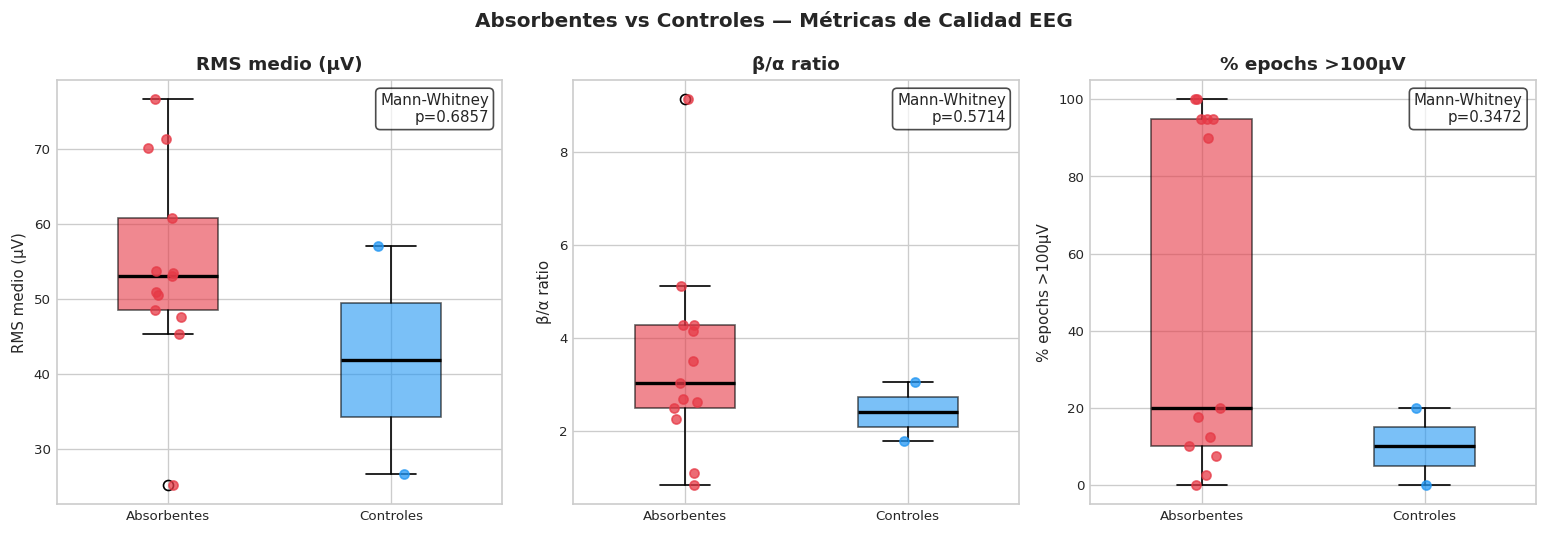

In [5]:
# ============================================================
# BLOQUE 3 — COMPARACIÓN: ABSORBENTES vs CONTROLES
# ============================================================

abs_ids  = [s for s in ABSORBING if s in results and 'error' not in results[s]]
ctrl_ids = [s for s in CONTROLS  if s in results and 'error' not in results[s]]

metrics_def = {
    'RMS medio (µV)':  lambda r: r['rms_mean'] * 1e6,
    'β/α ratio':       lambda r: r['ratio_beta_alpha'],
    '% epochs >100µV': lambda r: r['pct_100uV'],
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, (label, fn) in zip(axes, metrics_def.items()):
    abs_vals  = [fn(results[s]) for s in abs_ids]
    ctrl_vals = [fn(results[s]) for s in ctrl_ids]

    bp = ax.boxplot([abs_vals, ctrl_vals],
                    labels=['Absorbentes', 'Controles'],
                    patch_artist=True, widths=0.45,
                    medianprops=dict(color='black', lw=2))
    bp['boxes'][0].set_facecolor('#E63946'); bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('#2196F3'); bp['boxes'][1].set_alpha(0.6)

    for j, (vals, col) in enumerate(zip([abs_vals, ctrl_vals],
                                         ['#E63946', '#2196F3'])):
        ax.scatter(np.random.normal(j+1, 0.05, len(vals)), vals,
                   alpha=0.75, s=30, zorder=3, color=col)

    if abs_vals and ctrl_vals:
        _, p = stats.mannwhitneyu(abs_vals, ctrl_vals, alternative='two-sided')
        ax.text(0.97, 0.97, f'Mann-Whitney\np={p:.4f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    ax.set_title(label, fontweight='bold')
    ax.set_ylabel(label)

plt.suptitle('Absorbentes vs Controles — Métricas de Calidad EEG',
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig('qc_comparison_boxplots')
plt.show()

---
## B4 — Espectros de Potencia

> Alta potencia en **20-45 Hz** (banda EMG) es indicador de contaminación muscular.  
> Si el espectro de un absorbente domina esa región → artefacto probable.

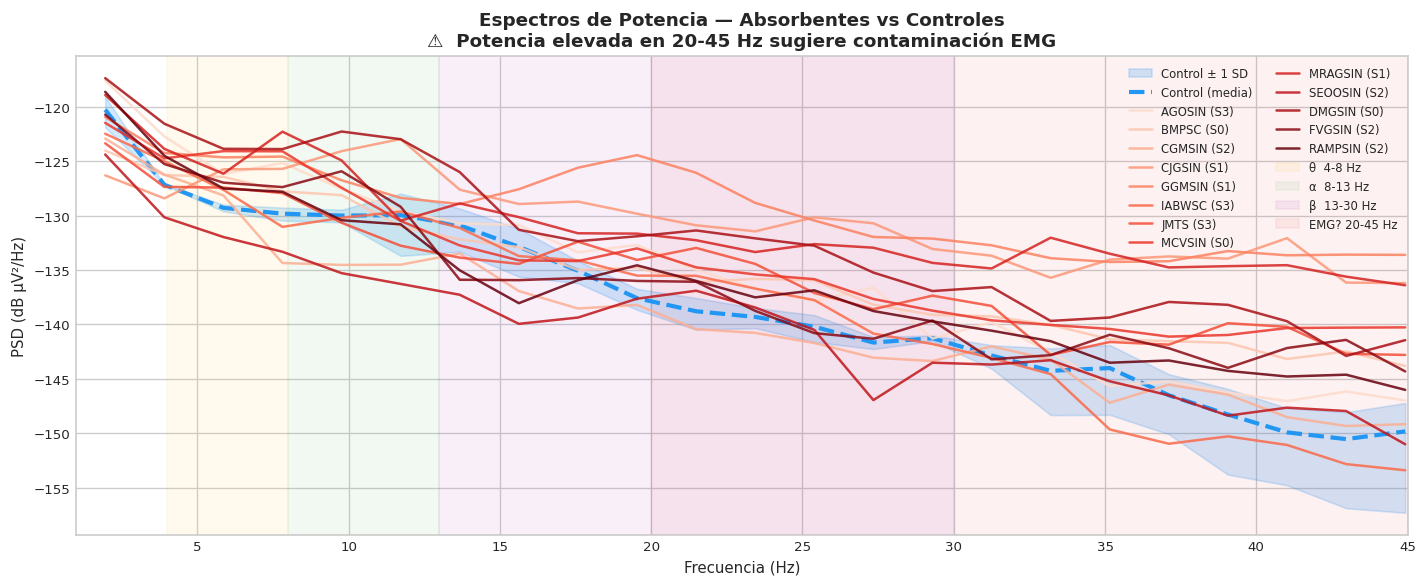


Ratio potencia EMG (20-45Hz) / total (1-45Hz):
  [Abs] AGOSIN        EMG ratio=0.043  🟢
  [Abs] BMPSC         EMG ratio=0.105  🟢
  [Abs] CGMSIN        EMG ratio=0.056  🟢
  [Abs] CJGSIN        EMG ratio=0.218  🟡
  [Abs] GGMSIN        EMG ratio=0.216  🟡
  [Abs] IABWSC        EMG ratio=0.060  🟢
  [Abs] JMTS          EMG ratio=0.137  🟢
  [Abs] MCVSIN        EMG ratio=0.081  🟢
  [Abs] MRAGSIN       EMG ratio=0.157  🟢
  [Abs] SEOOSIN       EMG ratio=0.104  🟢
  [Abs] DMGSIN        EMG ratio=0.069  🟢
  [Abs] FVGSIN        EMG ratio=0.056  🟢
  [Abs] RAMPSIN       EMG ratio=0.062  🟢
  [Ctrl] AAELSC        EMG ratio=0.074  🟢
  [Ctrl] AAGFSC        EMG ratio=0.027  🟢


In [6]:
# ============================================================
# BLOQUE 4 — ESPECTROS DE POTENCIA
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

# Controles: banda sombreada media ± 1 SD
if ctrl_ids:
    ctrl_psds = np.array([results[s]['psd_mean'] for s in ctrl_ids])
    freqs_ref = results[ctrl_ids[0]]['freqs']
    ctrl_mu   = ctrl_psds.mean(axis=0)
    ctrl_sd   = ctrl_psds.std(axis=0)
    ax.fill_between(
        freqs_ref,
        10 * np.log10(np.maximum(ctrl_mu - ctrl_sd, 1e-30)),
        10 * np.log10(ctrl_mu + ctrl_sd),
        alpha=0.20, color='#2196F3', label='Control ± 1 SD')
    ax.plot(freqs_ref, 10 * np.log10(ctrl_mu + 1e-30),
            color='#2196F3', lw=2.5, linestyle='--', label='Control (media)')

# Absorbentes: una línea por sujeto, degradado rojo
cmap_abs = plt.cm.get_cmap('Reds', len(abs_ids) + 2)
for ki, sid in enumerate(abs_ids):
    r = results[sid]
    ax.plot(r['freqs'], 10 * np.log10(r['psd_mean'] + 1e-30),
            color=cmap_abs(ki + 2), lw=1.5, alpha=0.85,
            label=f"{sid} ({ABSORBING.get(sid, '?')})")

# Sombreado de bandas
for (flo, fhi), name, color in [
        (THETA_BAND, 'θ  4-8 Hz',   '#FFC107'),
        (ALPHA_BAND, 'α  8-13 Hz',  '#4CAF50'),
        (BETA_BAND,  'β  13-30 Hz', '#9C27B0'),
        (EMG_BAND,   'EMG? 20-45 Hz', '#E63946')]:
    ax.axvspan(flo, fhi, alpha=0.07, color=color, label=name)

ax.set_xlabel('Frecuencia (Hz)')
ax.set_ylabel('PSD (dB µV²/Hz)')
ax.set_xlim(1, 45)
ax.set_title('Espectros de Potencia — Absorbentes vs Controles\n'
             '⚠️  Potencia elevada en 20-45 Hz sugiere contaminación EMG',
             fontweight='bold')
ax.legend(fontsize=7, ncol=2, loc='upper right', framealpha=0.85)
plt.tight_layout()
save_fig('qc_spectra')
plt.show()

# Tabla de ratio EMG por sujeto
print("\nRatio potencia EMG (20-45Hz) / total (1-45Hz):")
for sid in abs_ids + ctrl_ids:
    r = results[sid]
    freqs_s   = r['freqs']
    psd_s     = r['psd_mean']
    emg_mask  = (freqs_s >= EMG_BAND[0]) & (freqs_s <= EMG_BAND[1])
    tot_mask  = (freqs_s >= 1)
    emg_ratio = (np.trapz(psd_s[emg_mask], freqs_s[emg_mask]) /
                 (np.trapz(psd_s[tot_mask], freqs_s[tot_mask]) + 1e-30))
    flag = '🔴' if emg_ratio > 0.35 else '🟡' if emg_ratio > 0.20 else '🟢'
    grupo = 'Abs' if sid in ABSORBING else 'Ctrl'
    print(f"  [{grupo}] {sid:12s}  EMG ratio={emg_ratio:.3f}  {flag}")

---
## B5 — Topomapas RMS

> Fila superior: RMS por canal en µV (escala hot_r — más rojo = más ruidoso).  
> Fila inferior: z-score RMS (azul = bajo, rojo = alto).  
> **X roja** = canal con |z| > 2 (marcado como malo).

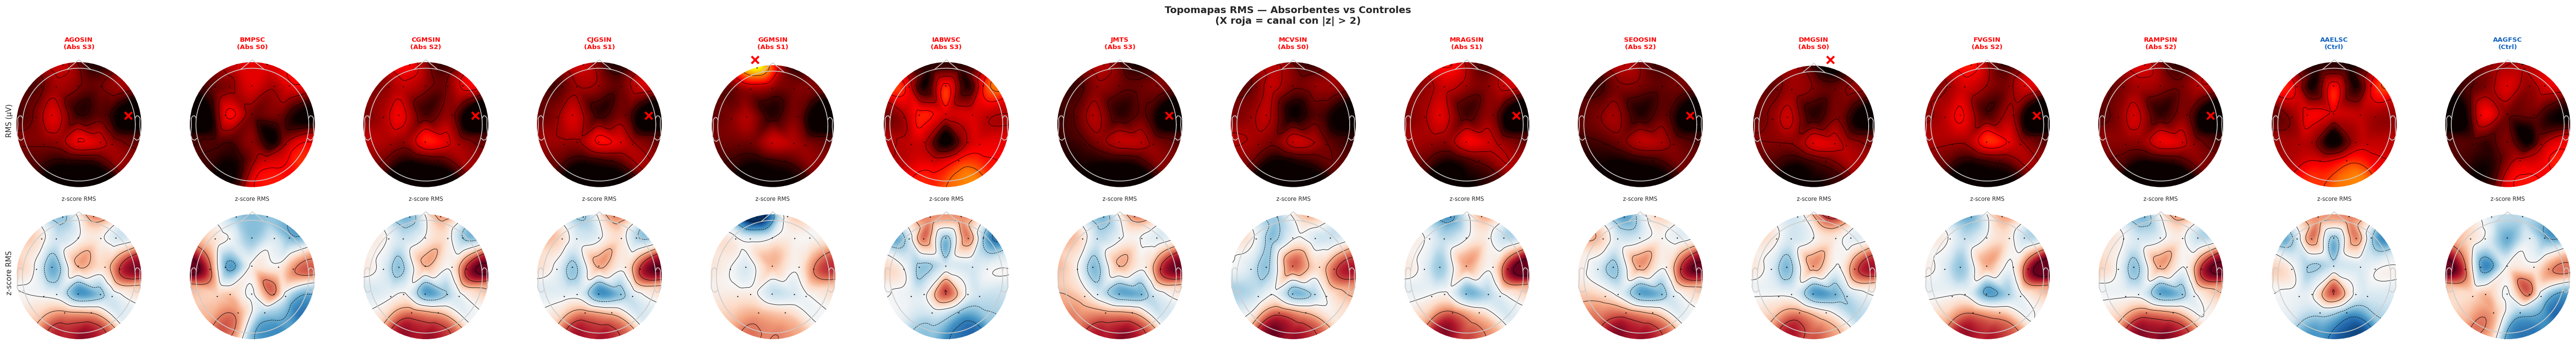

In [7]:
# ============================================================
# BLOQUE 5 — TOPOMAPAS RMS
# ============================================================

valid_ids = abs_ids + ctrl_ids

if not valid_ids:
    print("❌ Sin datos válidos para topomapas.")
else:
    n_plot = len(valid_ids)
    fig, axes = plt.subplots(2, n_plot,
                             figsize=(max(3 * n_plot, 8), 6))
    if n_plot == 1:
        axes = axes.reshape(2, 1)

    for col, sid in enumerate(valid_ids):
        r     = results[sid]
        grupo = f"Abs {ABSORBING[sid]}" if sid in ABSORBING else 'Ctrl'
        title = f"{sid}\n({grupo})"
        color = 'red' if sid in ABSORBING else '#1565C0'

        # --- Fila 0: topomap RMS en µV ---
        try:
            rms_uv = r['rms_ch'] * 1e6
            vmax   = np.percentile(rms_uv, 97)
            mne.viz.plot_topomap(
                rms_uv, r['epochs'].info,
                axes=axes[0, col], show=False,
                vlim=(0, vmax), cmap='hot_r', contours=4)
            axes[0, col].set_title(title, fontsize=8,
                                   fontweight='bold', color=color)

            # Marcar canales malos con X roja
            if r['bad_chs']:
                ch_pos = np.array([
                    r['epochs'].info['chs'][r['epochs'].ch_names.index(ch)]['loc'][:2]
                    for ch in r['bad_chs']
                ])
                axes[0, col].scatter(
                    ch_pos[:, 0], ch_pos[:, 1],
                    s=80, c='red', marker='x', zorder=5, linewidths=2.5)
        except Exception as exc:
            axes[0, col].set_title(f"{sid}\n(error)", fontsize=8, color='gray')
            axes[0, col].text(0.5, 0.5, str(exc)[:50],
                              transform=axes[0, col].transAxes,
                              ha='center', va='center', fontsize=6, wrap=True)

        # --- Fila 1: topomap z-score RMS ---
        try:
            mne.viz.plot_topomap(
                r['rms_z'], r['epochs'].info,
                axes=axes[1, col], show=False,
                vlim=(-3, 3), cmap='RdBu_r', contours=4)
            axes[1, col].set_title('z-score RMS', fontsize=7)
        except Exception as exc:
            axes[1, col].text(0.5, 0.5, 'error',
                              transform=axes[1, col].transAxes,
                              ha='center', va='center', fontsize=8)

    axes[0, 0].set_ylabel('RMS (µV)', fontsize=9)
    axes[1, 0].set_ylabel('z-score RMS', fontsize=9)
    plt.suptitle('Topomapas RMS — Absorbentes vs Controles\n'
                 '(X roja = canal con |z| > 2)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    save_fig('qc_topomaps_rms')
    plt.show()

---
## B6 — Veredictos Finales

Criterios de clasificación:

| Veredicto | Criterio |
|---|---|
| **Artefacto** | (RMS🔴 o EMG🔴) **Y** (bad_chs > 2 o EMG ratio > 0.35) |
| **Atípico** | RMS🟡, EMG🟡, bad_chs > 2, o > 20% epochs > 100µV |
| **OK** | Ninguno de los anteriores — absorción probablemente genuina |

In [8]:
# ============================================================
# BLOQUE 6 — VEREDICTOS FINALES
# ============================================================

verdict_rows = []

for sid in abs_ids + ctrl_ids:
    r = results[sid]
    if 'error' in r:
        verdict_rows.append({
            'Sujeto':     sid,
            'Grupo':      'Absorbente' if sid in ABSORBING else 'Control',
            'Estado':     ABSORBING.get(sid, '—'),
            'RMS_flag':   '❌', 'EMG_flag': '❌',
            'EMG ratio':  np.nan, 'Bad chs': '?',
            'Bad epochs': '?', 'β/α': np.nan,
            'Veredicto':  '❌ ERROR CARGA',
        })
        continue

    # --- Flag RMS ---
    rms_flag = ('🔴' if r['rms_mean'] > RMS_RED
                else '🟡' if r['rms_mean'] > RMS_YELLOW
                else '🟢')

    # --- Flag EMG: ratio potencia 20-45Hz sobre 1-45Hz ---
    freqs_s  = r['freqs']
    psd_s    = r['psd_mean']
    emg_mask = (freqs_s >= EMG_BAND[0]) & (freqs_s <= EMG_BAND[1])
    tot_mask = (freqs_s >= 1)
    emg_ratio = (np.trapz(psd_s[emg_mask], freqs_s[emg_mask]) /
                 (np.trapz(psd_s[tot_mask], freqs_s[tot_mask]) + 1e-30))
    emg_flag = ('🔴' if emg_ratio > 0.35
                else '🟡' if emg_ratio > 0.20
                else '🟢')

    # --- Veredicto ---
    is_red = (rms_flag == '🔴' or emg_flag == '🔴' or r['pct_200uV'] > 10)
    is_yel = (rms_flag == '🟡' or emg_flag == '🟡'
              or r['n_bad_chs'] > 2 or r['pct_100uV'] > 20)

    if is_red and (r['n_bad_chs'] > 2 or emg_ratio > 0.35):
        verdict = 'Artefacto'
    elif is_red or is_yel:
        verdict = 'Atípico'
    else:
        verdict = 'OK'

    verdict_rows.append({
        'Sujeto':     sid,
        'Grupo':      'Absorbente' if sid in ABSORBING else 'Control',
        'Estado':     ABSORBING.get(sid, '—'),
        'RMS_flag':   rms_flag,
        'EMG_flag':   emg_flag,
        'EMG ratio':  round(emg_ratio, 3),
        'Bad chs':    r['n_bad_chs'],
        'Bad epochs': f"{r['pct_200uV']:.1f}%",
        'β/α':        round(r['ratio_beta_alpha'], 3),
        'Veredicto':  verdict,
    })

df_verdict = pd.DataFrame(verdict_rows).set_index('Sujeto')
display(Markdown("### Veredictos QC — Absorbentes vs Controles"))
display(df_verdict)

# --- Recomendaciones ---
n_artefacto = sum(1 for r in verdict_rows if r['Veredicto'] == 'Artefacto')
n_atipico   = sum(1 for r in verdict_rows if r['Veredicto'] == 'Atípico')
n_ok        = sum(1 for r in verdict_rows if r['Veredicto'] == 'OK')

print(f"\n{'='*60}")
print(f"VEREDICTO FINAL — {len(abs_ids)} absorbentes analizados")
print(f"{'='*60}")
print(f"  🔴 Artefacto : {n_artefacto}")
print(f"  🟡 Atípico   : {n_atipico}")
print(f"  🟢 OK        : {n_ok}")
print(f"\nRecomendaciones por sujeto:")
icons = {'Artefacto': '🔴', 'Atípico': '🟡', 'OK': '🟢'}
recs  = {
    'Artefacto': 'Excluir del análisis HMM',
    'Atípico':   'Revisar manualmente antes de incluir',
    'OK':        'Mantener — absorción probablemente genuina',
}
for row in verdict_rows:
    if row['Sujeto'] not in ABSORBING:
        continue
    icon = icons[row['Veredicto']]
    rec  = recs[row['Veredicto']]
    print(f"  {icon} {row['Sujeto']:12s} ({row['Estado']}): {rec}")

### Veredictos QC — Absorbentes vs Controles

,Grupo,Estado,RMS_flag,EMG_flag,EMG ratio,Bad chs,Bad epochs,β/α,Veredicto
Sujeto,,,,,,,,,
AGOSIN,Absorbente,S3,🟡,🟢,0.043,1,0.0%,3.510,Atípico
BMPSC,Absorbente,S0,🟢,🟢,0.105,0,0.0%,2.703,OK
CGMSIN,Absorbente,S2,🟢,🟢,0.056,1,0.0%,3.033,OK
CJGSIN,Absorbente,S1,🟡,🟡,0.218,1,0.0%,2.502,Atípico
GGMSIN,Absorbente,S1,🟡,🟡,0.216,1,15.0%,9.130,Atípico
IABWSC,Absorbente,S3,🟢,🟢,0.060,0,0.0%,2.637,OK
JMTS,Absorbente,S3,🟡,🟢,0.137,1,0.0%,5.120,Atípico
MCVSIN,Absorbente,S0,🟡,🟢,0.081,0,0.0%,4.157,Atípico
MRAGSIN,Absorbente,S1,🟡,🟢,0.157,1,0.0%,4.279,Atípico



VEREDICTO FINAL — 13 absorbentes analizados
  🔴 Artefacto : 0
  🟡 Atípico   : 10
  🟢 OK        : 5

Recomendaciones por sujeto:
  🟡 AGOSIN       (S3): Revisar manualmente antes de incluir
  🟢 BMPSC        (S0): Mantener — absorción probablemente genuina
  🟢 CGMSIN       (S2): Mantener — absorción probablemente genuina
  🟡 CJGSIN       (S1): Revisar manualmente antes de incluir
  🟡 GGMSIN       (S1): Revisar manualmente antes de incluir
  🟢 IABWSC       (S3): Mantener — absorción probablemente genuina
  🟡 JMTS         (S3): Revisar manualmente antes de incluir
  🟡 MCVSIN       (S0): Revisar manualmente antes de incluir
  🟡 MRAGSIN      (S1): Revisar manualmente antes de incluir
  🟡 SEOOSIN      (S2): Revisar manualmente antes de incluir
  🟡 DMGSIN       (S0): Revisar manualmente antes de incluir
  🟢 FVGSIN       (S2): Mantener — absorción probablemente genuina
  🟡 RAMPSIN      (S2): Revisar manualmente antes de incluir
